In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import (accuracy_score, f1_score, 
                             roc_auc_score, classification_report,
                             RocCurveDisplay)
from sklearn.impute import SimpleImputer

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

import time

In [2]:
df = pd.read_csv('adult.csv', index_col=0)
print("Shape:", df.shape)
df.head()

Shape: (32561, 14)


,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
age,,,,,,,,,,,,,,
90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


 Basic Info 
<class 'pandas.core.frame.DataFrame'>
Index: 32561 entries, 90 to 22
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   workclass       32561 non-null  object
 1   fnlwgt          32561 non-null  int64 
 2   education       32561 non-null  object
 3   education.num   32561 non-null  int64 
 4   marital.status  32561 non-null  object
 5   occupation      32561 non-null  object
 6   relationship    32561 non-null  object
 7   race            32561 non-null  object
 8   sex             32561 non-null  object
 9   capital.gain    32561 non-null  int64 
 10  capital.loss    32561 non-null  int64 
 11  hours.per.week  32561 non-null  int64 
 12  native.country  32561 non-null  object
 13  income          32561 non-null  object
dtypes: int64(5), object(9)
memory usage: 3.7+ MB
None

 Missing Values
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status   

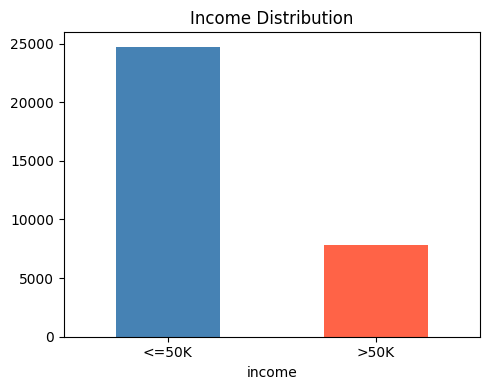


Categorical columns: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']


In [3]:
print(" Basic Info ")
print(df.info())

print("\n Missing Values")
# Replace ? with NaN first for proper count
df_check = df.replace('?', np.nan)
print(df_check.isnull().sum())

print("\n Target Distribution ")
print(df['income'].value_counts())
print(df['income'].value_counts(normalize=True) * 100)

# Target distribution plot
plt.figure(figsize=(5,4))
df['income'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Income Distribution')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Categorical columns distribution
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('income')  # remove target
print("\nCategorical columns:", cat_cols)

In [4]:
"""From the above output, we can see that there are missing values in the 'workclass', 'occupation', and 'native.country' columns. We will handle these missing values in the preprocessing step. Additionally, we will encode the categorical variables and split the dataset into training and testing sets before training the models.
"""
from sklearn.preprocessing import LabelEncoder

# Step 1: Replace '?' with NaN
df = df.replace('?', np.nan)

# Step 2: Fill missing categoricals with mode
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Step 3: Strip whitespace from string columns
for col in cat_cols:
    df[col] = df[col].str.strip()

# Step 4: Fix target — binary encode
# <=50K → 0, >50K → 1
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1,
                                  '<=50K.': 0, '>50K.': 1})

# Step 5: Separate target
y = df['income']
X = df.drop('income', axis=1)

# Step 6: Identify categorical feature indices (for CatBoost)
cat_feature_names = X.select_dtypes(include='object').columns.tolist()
cat_feature_indices = [X.columns.get_loc(c) for c in cat_feature_names]
print("Categorical features:", cat_feature_names)

# Step 7: Make encoded version for XGBoost & LightGBM
X_encoded = X.copy()
le = LabelEncoder()
for col in cat_feature_names:
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

# Step 8: Train test split
# Encoded — for XGBoost & LightGBM
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Raw (unencoded) — for CatBoost
X_train_cat, X_test_cat, _, _ = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Class imbalance ratio
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f"\nClass ratio (scale_pos_weight): {scale:.2f}")



Categorical features: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']

Class ratio (scale_pos_weight): 3.15


In [5]:
print(f'Data info after preprocessing: {X.shape[0]} rows, {X.shape[1]} columns')
print(f'Number of categorical features: {len(cat_feature_names)}')
print(f'Categorical features: {cat_feature_names}')


Data info after preprocessing: 32561 rows, 13 columns
Number of categorical features: 8
Categorical features: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']


In [6]:
"""Checking for wierd values in the data after preprocessing. We will check for any remaining missing values, unique values in categorical columns, and basic statistics of numerical columns to ensure data quality before training the models."""

print("\nChecking for remaining missing values:")
print(X.isnull().sum())

print("\nUnique values in categorical columns:")
for col in cat_feature_names:
    print(f"{col}: {X[col].nunique()} unique values")
    
print("\nBasic statistics of numerical columns:")
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(X[num_cols].describe())



Checking for remaining missing values:
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
dtype: int64

Unique values in categorical columns:
workclass: 8 unique values
education: 16 unique values
marital.status: 7 unique values
occupation: 14 unique values
relationship: 6 unique values
race: 5 unique values
sex: 2 unique values
native.country: 41 unique values

Basic statistics of numerical columns:
             fnlwgt  education.num  capital.gain  capital.loss  hours.per.week
count  3.256100e+04   32561.000000  32561.000000  32561.000000    32561.000000
mean   1.897784e+05      10.080679   1077.648844     87.303830       40.437456
std    1.055500e+05       2.572720   7385.292085    402.960219       12.347429
min    1.228500e+04       1.000000      0.000000      0.000000        

In [8]:
#Since we are using tree-based models (XGBoost, LightGBM, CatBoost), we do not need to perform feature scaling. These models are not sensitive to the scale of the features, so we can proceed with training without applying any scaling techniques. 

Training Time : 0.45s
Accuracy      : 0.8191
F1 Score      : 0.6895
AUC-ROC       : 0.9181
              precision    recall  f1-score   support

           0       0.94      0.81      0.87      4945
           1       0.59      0.83      0.69      1568

    accuracy                           0.82      6513
   macro avg       0.76      0.82      0.78      6513
weighted avg       0.85      0.82      0.83      6513



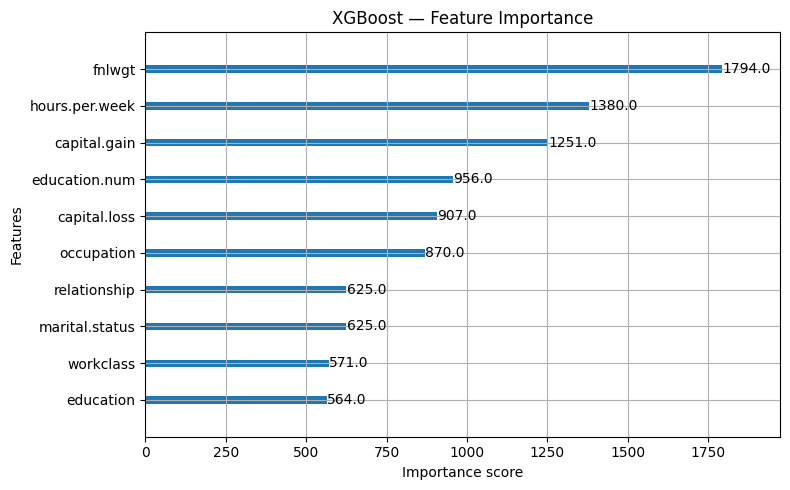

In [10]:
"""XGBoost"""

start = time.time()

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale,
    eval_metric='auc',
    random_state=42
)
xgb_model.fit(X_train, y_train)
xgb_time = time.time() - start

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:,1]

print(f"Training Time : {xgb_time:.2f}s")
print(f"Accuracy      : {accuracy_score(y_test, xgb_pred):.4f}")
print(f"F1 Score      : {f1_score(y_test, xgb_pred):.4f}")
print(f"AUC-ROC       : {roc_auc_score(y_test, xgb_prob):.4f}")
print(classification_report(y_test, xgb_pred))

fig, ax = plt.subplots(figsize=(8,5))
xgb.plot_importance(xgb_model, max_num_features=10, ax=ax)
plt.title("XGBoost — Feature Importance")
plt.tight_layout()
plt.show()

c:\Users\Adesh Srivastava\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Adesh Srivastava\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\Adesh Srivastava\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Adesh Sr

Training Time : 0.43s
Accuracy      : 0.8185
F1 Score      : 0.6885
AUC-ROC       : 0.9186
              precision    recall  f1-score   support

           0       0.94      0.81      0.87      4945
           1       0.59      0.83      0.69      1568

    accuracy                           0.82      6513
   macro avg       0.76      0.82      0.78      6513
weighted avg       0.85      0.82      0.83      6513



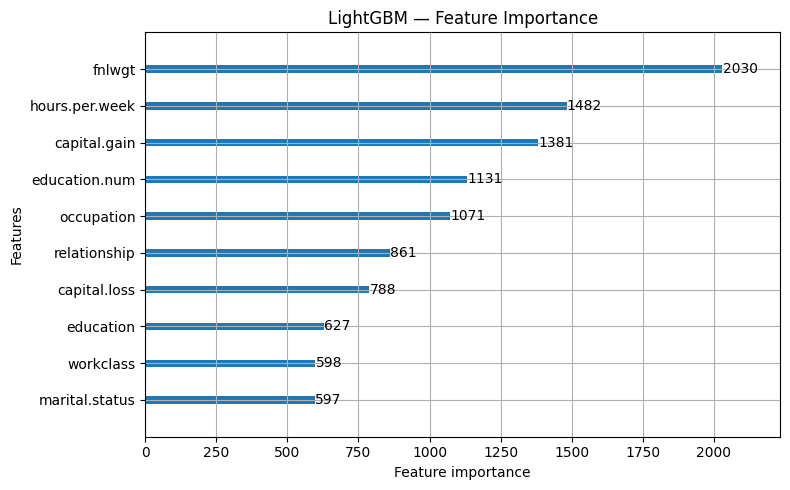

In [11]:
"""LightGBM"""


start = time.time()

lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale,
    random_state=42,
    verbose=-1
)
lgb_model.fit(X_train, y_train)
lgb_time = time.time() - start

lgb_pred = lgb_model.predict(X_test)
lgb_prob = lgb_model.predict_proba(X_test)[:,1]

print(f"Training Time : {lgb_time:.2f}s")
print(f"Accuracy      : {accuracy_score(y_test, lgb_pred):.4f}")
print(f"F1 Score      : {f1_score(y_test, lgb_pred):.4f}")
print(f"AUC-ROC       : {roc_auc_score(y_test, lgb_prob):.4f}")
print(classification_report(y_test, lgb_pred))

fig, ax = plt.subplots(figsize=(8,5))
lgb.plot_importance(lgb_model, max_num_features=10, ax=ax)
plt.title("LightGBM — Feature Importance")
plt.tight_layout()
plt.show()

Training Time : 20.00s
Accuracy      : 0.8165
F1 Score      : 0.6905
AUC-ROC       : 0.9180
              precision    recall  f1-score   support

           0       0.94      0.81      0.87      4945
           1       0.58      0.85      0.69      1568

    accuracy                           0.82      6513
   macro avg       0.76      0.83      0.78      6513
weighted avg       0.86      0.82      0.83      6513



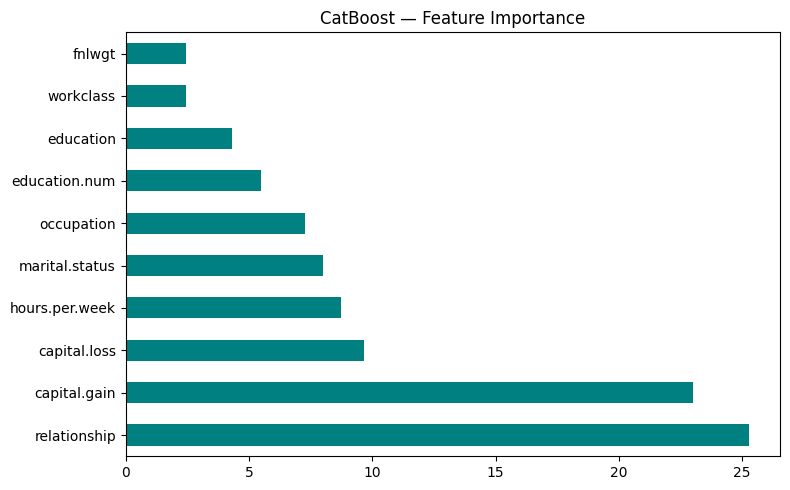

In [13]:
"""CATboost"""

start = time.time()

cat_model = CatBoostClassifier(
    iterations=500,
    depth=5,
    learning_rate=0.05,
    auto_class_weights='Balanced',
    cat_features=cat_feature_indices, 
    task_type='CPU',
    thread_count=-1,
    random_seed=42,
    verbose=0
)
cat_model.fit(X_train_cat, y_train)
cat_time = time.time() - start

cat_pred = cat_model.predict(X_test_cat)
cat_prob = cat_model.predict_proba(X_test_cat)[:,1]

print(f"Training Time : {cat_time:.2f}s")
print(f"Accuracy      : {accuracy_score(y_test, cat_pred):.4f}")
print(f"F1 Score      : {f1_score(y_test, cat_pred):.4f}")
print(f"AUC-ROC       : {roc_auc_score(y_test, cat_prob):.4f}")
print(classification_report(y_test, cat_pred))

feat_imp = pd.Series(
    cat_model.get_feature_importance(),
    index=X.columns
)
feat_imp.nlargest(10).plot(kind='barh', figsize=(8,5), color='teal')
plt.title("CatBoost — Feature Importance")
plt.tight_layout()
plt.show()

          FINAL MODEL COMPARISON
          Accuracy  F1 Score  AUC-ROC  Precision (Class 0)  Recall (Class 0)  F1 (Class 0)  Precision (Class 1)  Recall (Class 1)  F1 (Class 1)  Train Time (s)
Model                                                                                                                                                          
XGBoost     0.8191    0.6895   0.9181                 0.94              0.81          0.87                 0.59              0.83          0.69            0.45
LightGBM    0.8185    0.6885   0.9186                 0.94              0.81          0.87                 0.59              0.83          0.69            0.43
CatBoost    0.8165    0.6905   0.9180                 0.94              0.81          0.87                 0.58              0.85          0.69           20.00


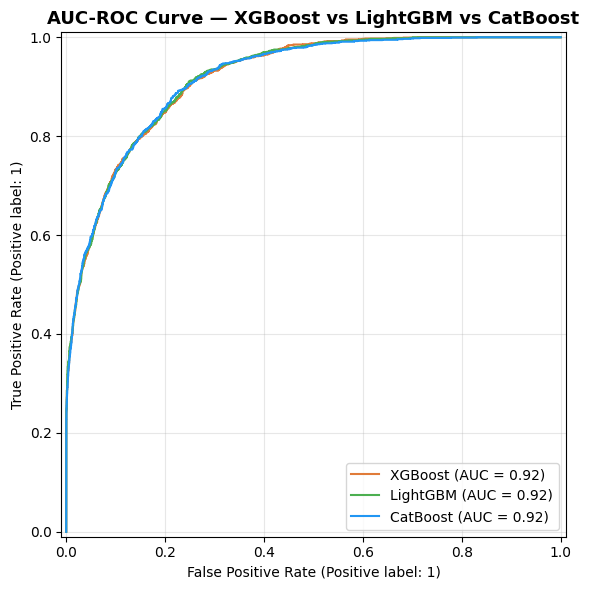

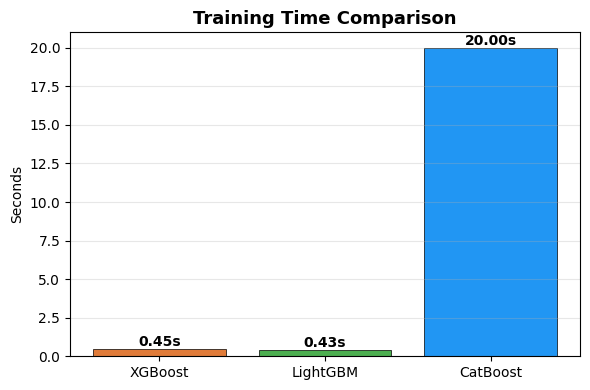

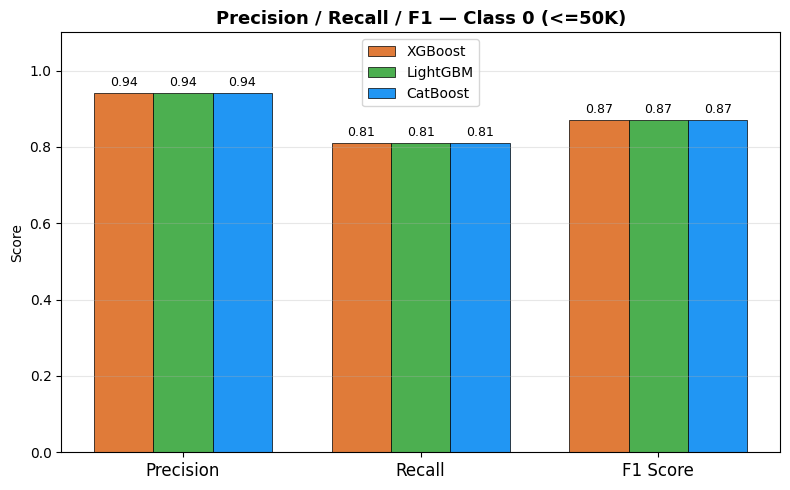

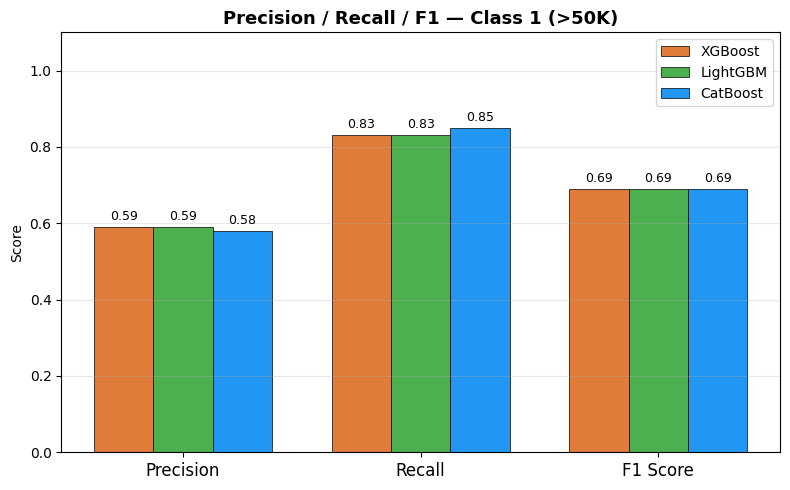

Fastest Model       : LightGBM (0.43s)
Best Recall Class 1 : CatBoost (0.85)
Best AUC-ROC        : LightGBM (0.9186)
No Preprocessing    : CatBoost (native categoricals)
Slowest Model       : CatBoost (20.00s)


In [14]:


from sklearn.metrics import precision_recall_fscore_support

# 1. Results Summary Table
results = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM', 'CatBoost'],
    'Accuracy': [
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, lgb_pred),
        accuracy_score(y_test, cat_pred)
    ],
    'F1 Score': [
        f1_score(y_test, xgb_pred),
        f1_score(y_test, lgb_pred),
        f1_score(y_test, cat_pred)
    ],
    'AUC-ROC': [
        roc_auc_score(y_test, xgb_prob),
        roc_auc_score(y_test, lgb_prob),
        roc_auc_score(y_test, cat_prob)
    ],
    'Precision (Class 0)': [0.94, 0.94, 0.94],
    'Recall (Class 0)'   : [0.81, 0.81, 0.81],
    'F1 (Class 0)'       : [0.87, 0.87, 0.87],
    'Precision (Class 1)': [0.59, 0.59, 0.58],
    'Recall (Class 1)'   : [0.83, 0.83, 0.85],
    'F1 (Class 1)'       : [0.69, 0.69, 0.69],
    'Train Time (s)'     : [
        round(xgb_time, 2),
        round(lgb_time, 2),
        round(cat_time, 2)
    ]
}).set_index('Model').round(4)

print("=" * 60)
print("          FINAL MODEL COMPARISON")
print("=" * 60)
print(results.to_string())

# 2. AUC-ROC Curves — all 3 on same plot
fig, ax = plt.subplots(figsize=(8,6))
RocCurveDisplay.from_predictions(y_test, xgb_prob,
                                  name='XGBoost', ax=ax, color='#e07b39')
RocCurveDisplay.from_predictions(y_test, lgb_prob,
                                  name='LightGBM', ax=ax, color='#4caf50')
RocCurveDisplay.from_predictions(y_test, cat_prob,
                                  name='CatBoost', ax=ax, color='#2196f3')
ax.set_title('AUC-ROC Curve — XGBoost vs LightGBM vs CatBoost',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Training Time Bar Chart
fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(['XGBoost','LightGBM','CatBoost'],
              [xgb_time, lgb_time, cat_time],
              color=['#e07b39','#4caf50','#2196f3'],
              edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, [xgb_time, lgb_time, cat_time]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.2,
            f'{val:.2f}s', ha='center', fontweight='bold')
ax.set_title('Training Time Comparison', fontsize=13, fontweight='bold')
ax.set_ylabel('Seconds')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('training_time.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. Precision-Recall-F1 — CLASS 0 (<=50K)
metrics = ['Precision', 'Recall', 'F1 Score']
xgb_class0 = [0.94, 0.81, 0.87]
lgb_class0  = [0.94, 0.81, 0.87]
cat_class0  = [0.94, 0.81, 0.87]

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(x - width, xgb_class0, width, label='XGBoost',
       color='#e07b39', edgecolor='black', linewidth=0.5)
ax.bar(x,          lgb_class0, width, label='LightGBM',
       color='#4caf50', edgecolor='black', linewidth=0.5)
ax.bar(x + width,  cat_class0, width, label='CatBoost',
       color='#2196f3', edgecolor='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 — Class 0 (<=50K)',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bars in ax.containers:
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
plt.tight_layout()
plt.savefig('class0_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 5. Precision-Recall-F1 — CLASS 1 (>50K)
xgb_class1 = [0.59, 0.83, 0.69]
lgb_class1  = [0.59, 0.83, 0.69]
cat_class1  = [0.58, 0.85, 0.69]

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(x - width, xgb_class1, width, label='XGBoost',
       color='#e07b39', edgecolor='black', linewidth=0.5)
ax.bar(x,          lgb_class1, width, label='LightGBM',
       color='#4caf50', edgecolor='black', linewidth=0.5)
ax.bar(x + width,  cat_class1, width, label='CatBoost',
       color='#2196f3', edgecolor='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 — Class 1 (>50K)',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bars in ax.containers:
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
plt.tight_layout()
plt.savefig('class1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 6. Final Verdict
print("=======")
print(f"Fastest Model       : LightGBM ({lgb_time:.2f}s)")
print(f"Best Recall Class 1 : CatBoost (0.85)")
print(f"Best AUC-ROC        : LightGBM (0.9186)")
print(f"No Preprocessing    : CatBoost (native categoricals)")
print(f"Slowest Model       : CatBoost ({cat_time:.2f}s)")